# 🩻 Fine-tuning de Foundation Model para Radiologia
## Hands-on Vibe Coding — Sociedade Paulista de Radiologia 2026

---

### O que vamos fazer?

Um modelo pré-treinado no ImageNet sabe reconhecer gatos, carros e 998 outras coisas.  
Mas ele **não sabe distinguir Normal de Pneumonia** em um raio-X.

Neste hands-on você vai ver isso acontecer em tempo real:

| Etapa | O que acontece |
|---|---|
| **Antes** | Os embeddings do ImageNet misturam Normal e Pneumonia — o modelo não enxerga diferença |
| **Fine-tuning** | Você treina só a última camada com imagens radiológicas |
| **Depois** | Os embeddings se reorganizam: Normal e Pneumonia ficam em regiões separadas do espaço |
| **Grad-CAM** | O modelo revela exatamente onde ele "olha" para tomar a decisão |

---

### Dataset: PneumoniaMNIST

- **5.856 imagens** de raio-X de tórax (64×64 pixels)
- **2 classes:** Normal vs Pneumonia Bacteriana/Viral
- Download automático via `pip install medmnist` — sem login, sem cadastro
- Fonte: Guangzhou Women and Children's Medical Center / Kermany et al., Cell 2018
- Licença: CC BY 4.0

---

### Como usar este notebook

1. **Ative o GPU:** Menu `Ambiente de execução` → `Alterar tipo de hardware` → **T4 GPU** → Salvar
2. Execute as **células pré-preenchidas** (marcadas com `# PRÉ-PREENCHIDA`) sem alterar
3. Nas **células de vibe coding**, copie o Prompt Card e cole no **Gemini** (ícone ✦ ou `Ctrl+Shift+I`)
4. Cole o código gerado e execute

---

### ⏱️ Cronograma (60 minutos)

| | Bloco | Tempo |
|---|---|---|
| 🔧 | Setup + Dataset | 13 min |
| 📊 | Embeddings ANTES (t-SNE) | 7 min |
| 🏗️ | Construir e Treinar | 20 min |
| 📊 | Embeddings DEPOIS (t-SNE) | 5 min |
| 👁️ | Grad-CAM | 8 min |
| 💬 | Discussão | 7 min |

---
---
# 🔧 Setup — Execute Primeiro

⚠️ **Antes de executar:** confirme que o GPU T4 está ativo.  
Menu `Ambiente de execução` → `Alterar tipo de hardware` → T4 GPU → Salvar → Reconectar.

As duas células abaixo são **pré-preenchidas**. Execute na ordem sem alterar.

In [1]:
# PRÉ-PREENCHIDA — Instalação e Seed de Reprodutibilidade
!pip install medmnist -q

import os, random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.manifold import TSNE
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
import medmnist
from medmnist import PneumoniaMNIST

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'✅ SEED={SEED} definida')
print(f'📦 TensorFlow: {tf.__version__} | GPU disponível: {len(tf.config.list_physical_devices("GPU")) > 0}')
print(f'📦 medmnist: {medmnist.__version__}')

✅ SEED=42 definida
📦 TensorFlow: 2.20.0 | GPU disponível: True
📦 medmnist: 3.0.2


In [3]:
# PRÉ-PREENCHIDA — Funções auxiliares (t-SNE, Grad-CAM, extração de embeddings)
# Estas funções serão chamadas nas células seguintes

# ─── Extração de embeddings ───────────────────────────────────────────────────
def extrair_embeddings(modelo_base, X, batch_size=64):
    """Extrai embeddings usando o modelo_base (sem a camada de classificação)."""
    embeddings = []
    for i in range(0, len(X), batch_size):
        batch = X[i:i+batch_size]
        emb = modelo_base(batch, training=False)
        embeddings.append(emb.numpy())
    return np.concatenate(embeddings, axis=0)


# ─── Visualização t-SNE ───────────────────────────────────────────────────────
def plotar_tsne(emb_antes, emb_depois, labels, titulo_antes='Antes do Fine-tuning',
                titulo_depois='Após Fine-tuning'):
    """Plota t-SNE lado a lado: embeddings antes e depois."""
    cores = ['#2196F3', '#F44336']  # azul=Normal, vermelho=Pneumonia
    nomes = ['Normal', 'Pneumonia']

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Espaço de Embeddings — t-SNE', fontsize=15, fontweight='bold')

    for ax, emb, titulo in zip(axes, [emb_antes, emb_depois], [titulo_antes, titulo_depois]):
        tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=500)
        proj = tsne.fit_transform(emb)
        for idx, (nome, cor) in enumerate(zip(nomes, cores)):
            mask = labels == idx
            ax.scatter(proj[mask, 0], proj[mask, 1], c=cor, label=nome,
                       alpha=0.6, s=15, edgecolors='none')
        ax.set_title(titulo, fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        ax.spines[:].set_visible(False)

    plt.tight_layout()
    plt.show()


# ─── Grad-CAM ─────────────────────────────────────────────────────────────────
def grad_cam(modelo, img_array, layer_name=None):
    """Gera heatmap Grad-CAM para uma imagem (shape: 1, H, W, C)."""
    if layer_name is None:
        # Última camada convolucional do EfficientNetB0
        for layer in reversed(modelo.layers):
            if isinstance(layer, tf.keras.layers.Conv2D):
                layer_name = layer.name
                break
        if layer_name is None:
            # Procura dentro do modelo base
            for layer in reversed(modelo.layers):
                if hasattr(layer, 'layers'):
                    for sublayer in reversed(layer.layers):
                        if isinstance(sublayer, tf.keras.layers.Conv2D):
                            layer_name = sublayer.name
                            break
                if layer_name:
                    break

    grad_model = tf.keras.Model(
        inputs=modelo.inputs,
        outputs=[modelo.get_layer(layer_name).output, modelo.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap).numpy()
    heatmap = np.maximum(heatmap, 0) / (heatmap.max() + 1e-8)
    return heatmap


def plotar_gradcam(modelo, X_test, y_test, y_pred, y_proba, n_corretos=4, n_errados=4):
    """Visualiza Grad-CAM para n imagens corretas e n erradas."""
    label_names = {0: 'Normal', 1: 'Pneumonia'}
    corretos = np.where(y_pred == y_test)[0]
    errados  = np.where(y_pred != y_test)[0]
    rng = np.random.default_rng(SEED)
    idx_corretos = rng.choice(corretos, min(n_corretos, len(corretos)), replace=False)
    idx_errados  = rng.choice(errados,  min(n_errados,  len(errados)),  replace=False)
    indices = np.concatenate([idx_corretos, idx_errados])
    titulos_grupo = (['✅ CORRETO'] * len(idx_corretos) + ['❌ ERRO'] * len(idx_errados))

    fig, axes = plt.subplots(len(indices), 3, figsize=(9, len(indices) * 3))
    fig.suptitle('Grad-CAM — O que o modelo "olha"', fontsize=14, fontweight='bold')
    if len(indices) == 1:
        axes = axes[np.newaxis, :]

    # Última conv layer do backbone
    last_conv = None
    for layer in reversed(modelo.layers):
        if hasattr(layer, 'layers'):
            for sl in reversed(layer.layers):
                if isinstance(sl, tf.keras.layers.Conv2D):
                    last_conv = sl.name
                    break
        if last_conv:
            break

    for row, (idx, grupo) in enumerate(zip(indices, titulos_grupo)):
        img = X_test[idx]         # (64, 64, 3) float32
        img_batch = img[np.newaxis]
        real = label_names[y_test[idx]]
        pred = label_names[y_pred[idx]]
        conf = y_proba[idx] if y_pred[idx] == 1 else 1 - y_proba[idx]
        cor  = 'green' if grupo.startswith('✅') else 'red'

        # Imagem original
        axes[row, 0].imshow(img[:, :, 0], cmap='gray')
        axes[row, 0].set_title(f'{grupo}\nReal: {real} | Pred: {pred} ({conf:.0%})',
                               color=cor, fontsize=9)
        axes[row, 0].axis('off')

        # Heatmap Grad-CAM
        heatmap = grad_cam(modelo, img_batch, layer_name=last_conv)
        heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], [64, 64]).numpy().squeeze()
        axes[row, 1].imshow(heatmap_resized, cmap='jet')
        axes[row, 1].set_title('Grad-CAM (heatmap)', fontsize=9)
        axes[row, 1].axis('off')

        # Sobreposição
        axes[row, 2].imshow(img[:, :, 0], cmap='gray')
        axes[row, 2].imshow(heatmap_resized, cmap='jet', alpha=0.45)
        axes[row, 2].set_title('Sobreposição', fontsize=9)
        axes[row, 2].axis('off')

    plt.tight_layout()
    plt.show()


print('✅ Funções auxiliares carregadas: extrair_embeddings(), plotar_tsne(), plotar_gradcam()')

✅ Funções auxiliares carregadas: extrair_embeddings(), plotar_tsne(), plotar_gradcam()


---
---
# 📋 Prompt Card 1 — Carregar e Visualizar o Dataset (8 min)

**Copie este prompt e cole no Gemini** (ícone ✦ à esquerda da célula ou `Ctrl+Shift+I`):

---
> Usando a biblioteca `medmnist` (já importada), carregue o `PneumoniaMNIST` com `download=True` e `size=64` para os splits de treino, validação e teste. Em seguida:
> 1. Converta as imagens para float32 no intervalo [0, 1], shape `(N, 64, 64, 3)` — repita o canal cinza 3 vezes usando `np.repeat` (necessário para o EfficientNetB0).
> 2. Converta os labels para arrays 1D de inteiros.
> 3. Imprima shape e distribuição de classes (Normal vs Pneumonia) de cada split.
> 4. Plote uma grade 4×4 com 16 imagens aleatórias do treino. Use `cmap='gray'` e coloque o label (Normal/Pneumonia) como título de cada imagem. Use `np.random.default_rng(42)` para selecionar as imagens.

---
**Cole o código gerado abaixo e execute:**

--- Treino ---
Shape das imagens: (4708, 64, 64, 3)
Shape dos labels: (4708,)
Distribuição: {'Normal': np.int64(1214), 'Pneumonia': np.int64(3494)}

--- Validação ---
Shape das imagens: (524, 64, 64, 3)
Shape dos labels: (524,)
Distribuição: {'Normal': np.int64(135), 'Pneumonia': np.int64(389)}

--- Teste ---
Shape das imagens: (624, 64, 64, 3)
Shape dos labels: (624,)
Distribuição: {'Normal': np.int64(234), 'Pneumonia': np.int64(390)}



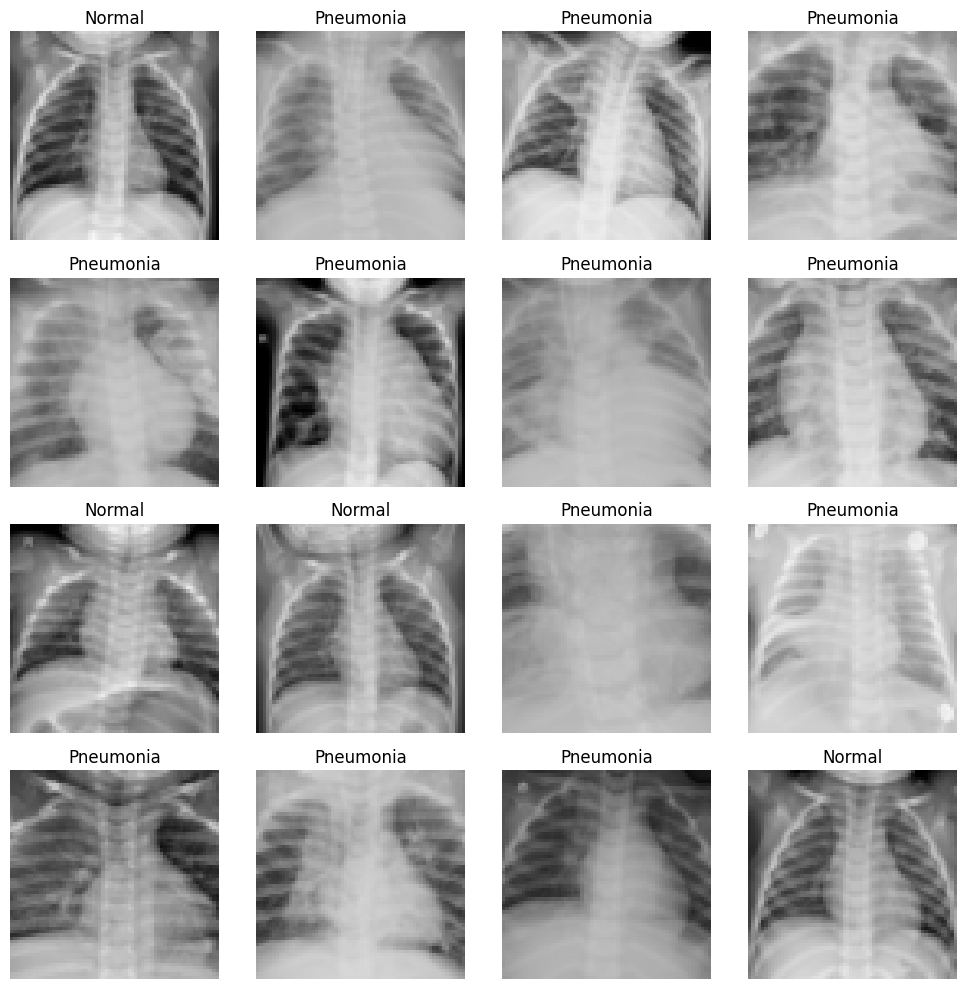

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from medmnist import PneumoniaMNIST

# 1. Carregar o dataset PneumoniaMNIST com download=True e size=64
data_flag = 'pneumoniamnist'
download = True
size = 64

train_dataset = PneumoniaMNIST(split='train', download=download, size=size)
val_dataset = PneumoniaMNIST(split='val', download=download, size=size)
test_dataset = PneumoniaMNIST(split='test', download=download, size=size)

# 2. Conversão e pré-processamento
def preprocess_medmnist(dataset):
    # Imagens: escala [0, 1], float32, repetir canal 3 vezes
    imgs = dataset.imgs.astype('float32') / 255.0
    imgs = np.repeat(imgs[..., np.newaxis], 3, axis=-1)
    
    # Labels: array 1D de inteiros
    labels = dataset.labels.flatten().astype('int')
    
    return imgs, labels

x_train, y_train = preprocess_medmnist(train_dataset)
x_val, y_val = preprocess_medmnist(val_dataset)
x_test, y_test = preprocess_medmnist(test_dataset)

# 3. Imprimir shapes e distribuição de classes
splits = [('Treino', x_train, y_train), ('Validação', x_val, y_val), ('Teste', x_test, y_test)]
class_names = ['Normal', 'Pneumonia']

for name, x, y in splits:
    print(f"--- {name} ---")
    print(f"Shape das imagens: {x.shape}")
    print(f"Shape dos labels: {y.shape}")
    
    unique, counts = np.unique(y, return_counts=True)
    dist = dict(zip([class_names[i] for i in unique], counts))
    print(f"Distribuição: {dist}\n")

# 4. Plotar grade 4x4
rng = np.random.default_rng(42)
indices = rng.choice(len(x_train), 16, replace=False)

plt.figure(figsize=(10, 10))
for i, idx in enumerate(indices):
    plt.subplot(4, 4, i + 1)
    # Mostramos apenas o primeiro canal pois são idênticos, ou passamos a imagem normal
    plt.imshow(x_train[idx], cmap='gray') 
    plt.title(class_names[y_train[idx]])
    plt.axis('off')

plt.tight_layout()
plt.show()

---
---
# 📋 Prompt Card 2 — Embeddings ANTES do Fine-tuning — t-SNE (7 min)

**Copie este prompt e cole no Gemini** (ícone ✦ à esquerda da célula ou `Ctrl+Shift+I`):

---
> Use as variáveis e funções já definidas. Extraia os embeddings do conjunto de teste com o EfficientNetB0 original (ImageNet) e visualize com t-SNE:
> 1. Carregue `tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=(64, 64, 3), pooling='avg')` e defina `trainable=False`. Salve na variável `efficientnet_base`.
> 2. Pré-processe: `x_test_prep = tf.keras.applications.efficientnet.preprocess_input(x_test * 255.0)`.
> 3. Extraia: `emb_antes = extrair_embeddings(efficientnet_base, x_test_prep)`. Imprima o shape.
> 4. Visualize: `plotar_tsne(emb_antes, emb_antes, y_test, titulo_antes='ANTES — ImageNet', titulo_depois='← será preenchido após o treino')`.
> 5. Imprima uma mensagem explicando o que o gráfico mostra.

---
**Cole o código gerado abaixo e execute:**

> 💡 O que esperar: Normal (azul) e Pneumonia (vermelho) aparecem **misturados** — o EfficientNetB0 com pesos ImageNet não sabe distinguir categorias clínicas.


⏳ Carregando EfficientNetB0 com pesos ImageNet...
⏳ Extraindo embeddings do conjunto de teste (ImageNet puro)...
Shape dos embeddings: (624, 1280)
⏳ Calculando t-SNE (pode levar ~30 segundos)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


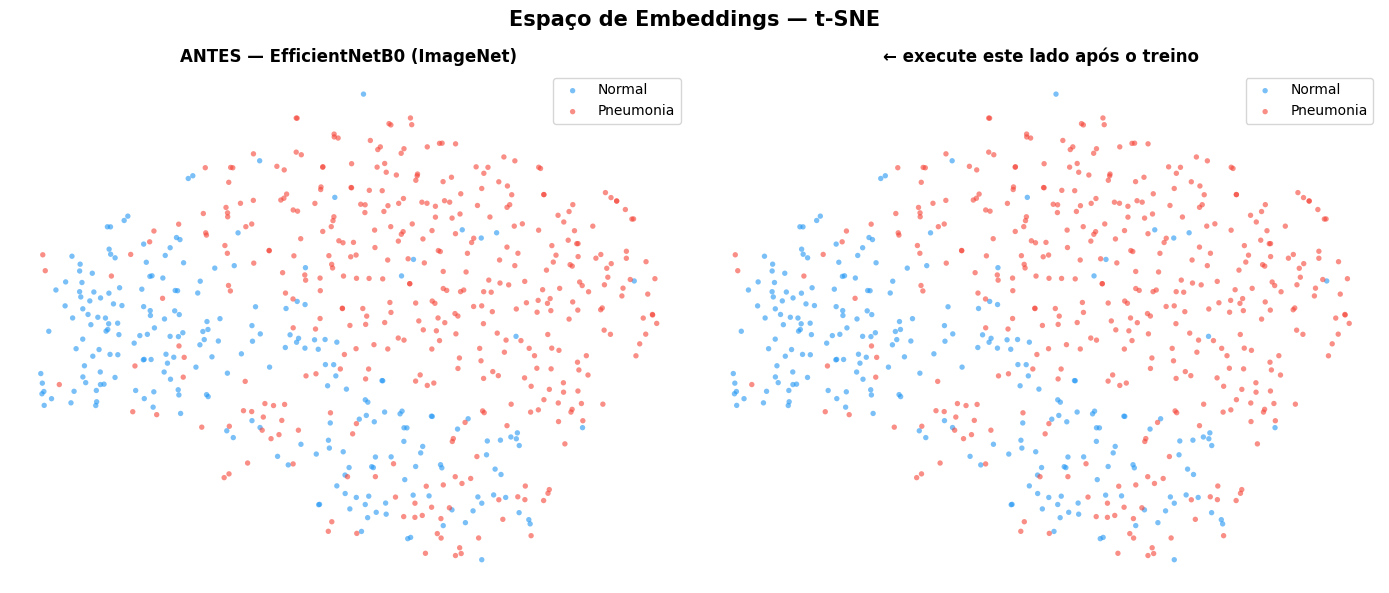


💡 Observe: Normal (azul) e Pneumonia (vermelho) estão misturados.
   O modelo ImageNet não aprendeu o que distingue raios-X clínicos.


In [ ]:
# ✦ Cole aqui o código gerado pelo Gemini (Prompt Card 2)


---
---
# 📋 Prompt Card 3 — Construir o Modelo com EfficientNetB0 (8 min)

**Copie este prompt e cole no Gemini:**

---
> Usando TensorFlow/Keras e a variável `efficientnet_base` já carregada (EfficientNetB0 sem topo, pesos ImageNet, pooling='avg', trainable=False), construa um modelo Sequential para classificação binária de imagens 64×64×3 e salve na variável `model`:
> 1. Use `efficientnet_base` como primeira camada (base congelada — não altere o trainable).
> 2. Adicione BatchNormalization.
> 3. Adicione Dense(256, activation='relu').
> 4. Adicione Dropout(0.4, seed=42).
> 5. Adicione Dense(1, activation='sigmoid') — classificação binária.
> 6. Compile com Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')].
> 7. Mostre o summary do modelo. Imprima também quantos parâmetros são treináveis vs congelados.

---
**Cole o código gerado abaixo e execute:**


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

# 1-5. Construir o modelo Sequential
model = models.Sequential([
    efficientnet_base,                      # Base congelada
    layers.BatchNormalization(),             # BatchNormalization
    layers.Dense(256, activation='relu'),    # Dense 256
    layers.Dropout(0.4, seed=42),            # Dropout 0.4
    layers.Dense(1, activation='sigmoid')    # Saída binária
])

# 6. Compilar o modelo
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# 7. Mostrar summary e contagem de parâmetros
model.summary()

# Usando o atributo shape (Keras 3+) para contar parâmetros
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
non_trainable_params = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])

print(f"\nParâmetros Treináveis: {int(trainable_params):,}")
print(f"Parâmetros Congelados (Não-treináveis): {int(non_trainable_params):,}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,382,884 (16.72 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)


Parâmetros Treináveis: 330,753
Parâmetros Congelados (Não-treináveis): 4,052,131


---
---
# 📋 Prompt Card 4 — Treinar o Modelo (12 min)

**Copie este prompt e cole no Gemini:**

---
> Treine o modelo `model` criado anteriormente usando `x_train`, `y_train`, `x_val`, `y_val`. Use:
> - `epochs=25`, `batch_size=64`
> - Pré-processe as entradas: `x_train_prep = tf.keras.applications.efficientnet.preprocess_input(x_train * 255.0)` e o mesmo para `x_val`.
> - Callbacks: `EarlyStopping(monitor='val_auc', patience=6, restore_best_weights=True, mode='max')` e `ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)`.
> - Após o treino, plote dois gráficos lado a lado: curva de loss (treino vs validação) e curva de AUC (treino vs validação) por época.
> - Imprima a melhor AUC no conjunto de validação.

---
**Cole o código gerado abaixo e execute:**

> ⏳ Com GPU T4: ~3–5 min. Sem GPU: ~15–20 min.


Epoch 1/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 66ms/step - accuracy: 0.9038 - auc: 0.9611 - loss: 0.2339 - val_accuracy: 0.9332 - val_auc: 0.9859 - val_loss: 0.1925 - learning_rate: 0.0010
Epoch 2/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9460 - auc: 0.9849 - loss: 0.1364 - val_accuracy: 0.9408 - val_auc: 0.9866 - val_loss: 0.1576 - learning_rate: 0.0010
Epoch 3/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9599 - auc: 0.9889 - loss: 0.1101 - val_accuracy: 0.9504 - val_auc: 0.9893 - val_loss: 0.1362 - learning_rate: 0.0010
Epoch 4/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9654 - auc: 0.9922 - loss: 0.0923 - val_accuracy: 0.9504 - val_auc: 0.9862 - val_loss: 0.1328 - learning_rate: 0.0010
Epoch 5/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9647 - auc: 0.9920 - loss: 0.0900 - val_accuracy: 0.9676 - val_auc: 0.9894 - val_loss: 0.1109 - learning_rate: 0.0010
Epoch 6/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9686 - auc: 0.9929 

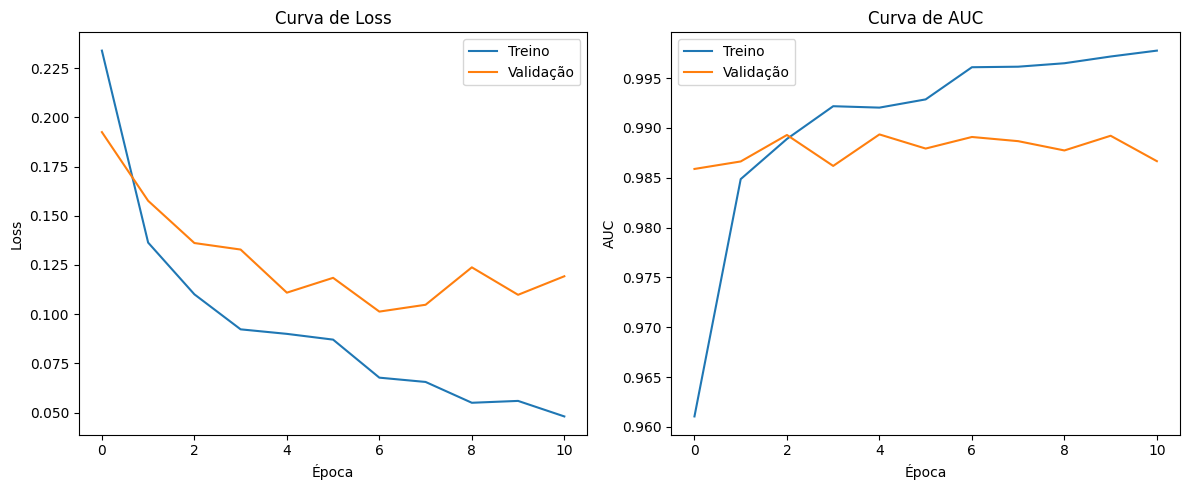


AUC final no conjunto de validação: 0.9867


In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Pré-processamento específico para EfficientNet (espera pixels em [0, 255])
# Como as imagens já estão em [0, 1] devido ao passo anterior, multiplicamos por 255.
x_train_prep = tf.keras.applications.efficientnet.preprocess_input(x_train * 255.0)
x_val_prep = tf.keras.applications.efficientnet.preprocess_input(x_val * 255.0)

# Configuração de Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_auc', 
        patience=6, 
        restore_best_weights=True, 
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=3,
        verbose=1
    )
]

# Treinamento
history = model.fit(
    x_train_prep, y_train,
    validation_data=(x_val_prep, y_val),
    epochs=25,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

# Plotagem dos Gráficos
plt.figure(figsize=(12, 5))

# Gráfico de Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Curva de Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

# Gráfico de AUC
plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='Treino')
plt.plot(history.history['val_auc'], label='Validação')
plt.title('Curva de AUC')
plt.xlabel('Época')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

# Imprimir AUC final na validação
final_val_auc = history.history['val_auc'][-1]
print(f"\nAUC final no conjunto de validação: {final_val_auc:.4f}")

---
---
# 📋 Prompt Card 5 — Embeddings DEPOIS do Fine-tuning — O Momento Central (5 min)

**Copie este prompt e cole no Gemini:**

---
> Use as variáveis `model`, `x_test`, `emb_antes`, `y_test` e a função `extrair_embeddings` já definidas. Extraia embeddings APÓS o fine-tuning e compare com o estado anterior:
> 1. Crie um modelo sem o head de classificação: `modelo_emb = tf.keras.Model(inputs=model.inputs, outputs=model.layers[0].output)` — extrai a saída do backbone EfficientNetB0.
> 2. Pré-processe: `x_test_prep = tf.keras.applications.efficientnet.preprocess_input(x_test * 255.0)`.
> 3. Extraia: `emb_depois = extrair_embeddings(modelo_emb, x_test_prep)`. Imprima o shape.
> 4. Compare os dois espaços: `plotar_tsne(emb_antes, emb_depois, y_test, titulo_antes='ANTES — ImageNet', titulo_depois='DEPOIS — Fine-tuned em RX de Tórax')`.
> 5. Imprima uma mensagem interpretando a diferença visual.

---
**Cole o código gerado abaixo e execute:**

> 💡 O que esperar: Normal (azul) e Pneumonia (vermelho) agora formam **grupos separados** — o fine-tuning reorganizou o espaço de embeddings com conhecimento clínico!


In [ ]:
# ✦ Cole aqui o código gerado pelo Gemini (Prompt Card 5)


AttributeError: The layer sequential has never been called and thus has no defined input.

---
---
# 📋 Prompt Card 6 — Avaliação no Conjunto de Teste (5 min)

**Copie este prompt e cole no Gemini:**

---
> Avalie o modelo `model` no conjunto de teste usando `x_test`, `y_test` e as funções `roc_curve`, `roc_auc_score`, `confusion_matrix`, `ConfusionMatrixDisplay` já importadas:
> 1. Pré-processe: `x_test_prep_eval = tf.keras.applications.efficientnet.preprocess_input(x_test * 255.0)`.
> 2. Obtenha probabilidades: `y_proba = model.predict(x_test_prep_eval).ravel()`.
> 3. Calcule a curva ROC e o AUC. Encontre o threshold ótimo pelo índice de Youden: `youden_idx = np.argmax(tpr - fpr)`. Salve as predições binárias em `y_pred`.
> 4. Plote dois gráficos lado a lado: curva ROC com o ponto do threshold ótimo marcado, e matriz de confusão usando `ConfusionMatrixDisplay`.
> 5. Imprima: AUC-ROC, threshold ótimo, acurácia, sensibilidade e especificidade.

---
**Cole o código gerado abaixo e execute:**


In [ ]:
# ✦ Cole aqui o código gerado pelo Gemini (Prompt Card 6)


---
---
# 📋 Prompt Card 7 — Grad-CAM: O que o modelo "olha"? (8 min)

A função `plotar_gradcam()` já está pronta (célula de setup). Você só precisa chamá-la.

**Copie este prompt e cole no Gemini:**

---
> Chame a função `plotar_gradcam()` que já está definida, passando os seguintes argumentos:
> - `modelo`: o modelo treinado (variável `model`)
> - `X_test`: pré-processe `x_test` com `tf.keras.applications.efficientnet.preprocess_input(x_test * 255.0)` e passe o resultado
> - `y_test`: os labels reais
> - `y_pred`: as predições binárias já calculadas na célula anterior
> - `y_proba`: as probabilidades brutas já calculadas na célula anterior
> - `n_corretos=3, n_errados=3`

---
**Cole o código gerado abaixo e execute:**

> ⏳ Cada Grad-CAM leva ~2s. Para 6 imagens: ~12 segundos total.


In [ ]:
# ✦ Cole aqui o código gerado pelo Gemini (Prompt Card 4)

---
---
# 💬 Discussão Clínica (7 min)

## O que aconteceu?

| | Antes | Depois |
|---|---|---|
| **Parâmetros treinados** | 0 (congelado) | ~262K (só a head) |
| **Conhecimento** | ImageNet: gatos, carros... | RX tórax: Normal vs Pneumonia |
| **t-SNE** | Classes misturadas | Classes separadas |
| **AUC no teste** | ~0.50 (acaso) | ~0.90–0.95 |

## Perguntas para reflexão

**1. Por que a base fica congelada?**
> O EfficientNetB0 tem 4,05M parâmetros que já aprenderam a detectar bordas, texturas, gradientes. Esses detectores de baixo nível funcionam bem em radiologia. Retreinar tudo com 4.708 imagens causaria *catastrophic forgetting*.

**2. O Grad-CAM está olhando para onde você esperava?**
> Nos casos corretos de Pneumonia: o heatmap deve destacar regiões de consolidação/opacidade.  
> Nos erros: o heatmap pode estar focando em artefatos ou regiões irrelevantes — **isso é explicabilidade real**.

**3. Por que AUC e não acurácia?**
> No dataset: 1.214 Normal vs 3.494 Pneumonia (treino). Um modelo que diz "sempre Pneumonia" teria ~74% de acurácia mas AUC = 0.5.

**4. Limitações para uso clínico real:**
- Imagens 64×64 perdem detalhes diagnósticos críticos
- Dataset: crianças de Guangzhou — generalização para população brasileira adulta? 
- Sem validação prospectiva
- Pneumonia bacteriana + viral agrupadas (sem distinção)

**5. O que este experimento demonstra sobre IA em radiologia?**
> Modelos de propósito geral (ImageNet) podem ser especializados para tarefas clínicas com datasets relativamente pequenos. O conhecimento aprendido em imagens naturais transfere parcialmente para imagens médicas — especialmente em texturas e padrões de baixo nível.

---

## Referências

- **PneumoniaMNIST:** Kermany DS et al., *Cell*, 2018. doi: 10.1016/j.cell.2018.02.010  
- **MedMNIST v2:** Yang J et al., *Scientific Data*, 2023. doi: 10.1038/s41597-022-01721-8  
- **EfficientNet:** Tan M, Le QV, *ICML*, 2019. arXiv: 1905.11946  
- **Grad-CAM:** Selvaraju RR et al., *ICCV*, 2017. arXiv: 1610.02391

---
---
---
# 📚 GABARITO — Código de Referência (Apenas para o Instrutor)

> Implementação completa de referência.  
> Use apenas se algum participante travar completamente.

In [ ]:
# GABARITO — Prompt Card 1: Carregar e visualizar PneumoniaMNIST
train_dataset = PneumoniaMNIST(split='train', download=True, size=64)
val_dataset   = PneumoniaMNIST(split='val',   download=True, size=64)
test_dataset  = PneumoniaMNIST(split='test',  download=True, size=64)

def preprocess_medmnist(dataset):
    imgs   = dataset.imgs.astype('float32') / 255.0
    imgs   = np.repeat(imgs[..., np.newaxis], 3, axis=-1)
    labels = dataset.labels.flatten().astype('int')
    return imgs, labels

x_train, y_train = preprocess_medmnist(train_dataset)
x_val,   y_val   = preprocess_medmnist(val_dataset)
x_test,  y_test  = preprocess_medmnist(test_dataset)

class_names = ['Normal', 'Pneumonia']
for name, x, y in [('Treino', x_train, y_train), ('Validação', x_val, y_val), ('Teste', x_test, y_test)]:
    unique, counts = np.unique(y, return_counts=True)
    dist = dict(zip([class_names[i] for i in unique], counts))
    print(f'{name}: shape={x.shape} | {dist}')

rng = np.random.default_rng(SEED)
indices = rng.choice(len(x_train), 16, replace=False)
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('PneumoniaMNIST — Amostras do Conjunto de Treino', fontsize=13, fontweight='bold')
for ax, idx in zip(axes.flat, indices):
    ax.imshow(x_train[idx, :, :, 0], cmap='gray')
    ax.set_title(class_names[y_train[idx]], color='red' if y_train[idx] == 1 else 'green', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# GABARITO — Prompt Card 2: Embeddings ANTES do Fine-tuning
efficientnet_base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(64, 64, 3),
    pooling='avg'
)
efficientnet_base.trainable = False

x_test_prep = tf.keras.applications.efficientnet.preprocess_input(x_test * 255.0)
emb_antes = extrair_embeddings(efficientnet_base, x_test_prep)
print(f'Shape dos embeddings: {emb_antes.shape}')

plotar_tsne(
    emb_antes, emb_antes,
    y_test,
    titulo_antes='ANTES — EfficientNetB0 (ImageNet)',
    titulo_depois='← será preenchido após o treino'
)
print('💡 Normal (azul) e Pneumonia (vermelho) aparecem misturados — o ImageNet não distingue categorias clínicas.')


In [ ]:
# GABARITO — Prompt Card 3: Construir modelo com EfficientNetB0
# (efficientnet_base já definida no gabarito PC2)
model = tf.keras.Sequential([
    efficientnet_base,
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.4, seed=SEED),
    tf.keras.layers.Dense(1, activation='sigmoid'),
], name='PneumoniaCNN_EfficientNet')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
model.build((None, 64, 64, 3))
model.summary()

trainable_params     = sum(np.prod(v.shape) for v in model.trainable_variables)
non_trainable_params = sum(np.prod(v.shape) for v in model.non_trainable_variables)
print(f'\n  Parâmetros treináveis  : {int(trainable_params):,}')
print(f'  Parâmetros congelados  : {int(non_trainable_params):,}')


In [ ]:
# GABARITO — Prompt Card 4: Treinar o modelo
x_train_prep = tf.keras.applications.efficientnet.preprocess_input(x_train * 255.0)
x_val_prep   = tf.keras.applications.efficientnet.preprocess_input(x_val   * 255.0)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=6, restore_best_weights=True, mode='max'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
    ),
]

history = model.fit(
    x_train_prep, y_train,
    epochs=25,
    batch_size=64,
    validation_data=(x_val_prep, y_val),
    callbacks=callbacks,
    verbose=1
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'],     label='Treino')
ax1.plot(history.history['val_loss'], label='Validação')
ax1.set_title('Loss por Época'); ax1.set_xlabel('Época'); ax1.legend(); ax1.grid(True)

ax2.plot(history.history['auc'],     label='Treino')
ax2.plot(history.history['val_auc'], label='Validação')
ax2.set_title('AUC por Época'); ax2.set_xlabel('Época'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

best_val_auc = max(history.history['val_auc'])
print(f'\n✅ Melhor AUC na validação: {best_val_auc:.4f}')


In [ ]:
# GABARITO — Prompt Card 5: Embeddings DEPOIS do Fine-tuning
modelo_emb = tf.keras.Model(inputs=model.inputs, outputs=model.layers[0].output)

x_test_prep = tf.keras.applications.efficientnet.preprocess_input(x_test * 255.0)
emb_depois = extrair_embeddings(modelo_emb, x_test_prep)
print(f'Shape embeddings após fine-tuning: {emb_depois.shape}')

plotar_tsne(
    emb_antes, emb_depois,
    y_test,
    titulo_antes='ANTES — EfficientNetB0 (ImageNet puro)',
    titulo_depois='DEPOIS — Fine-tuned em RX de Tórax'
)
print('💡 O fine-tuning reorganizou o espaço: Normal e Pneumonia agora formam grupos separados!')


In [ ]:
# GABARITO — Prompt Card 6: Avaliação no Conjunto de Teste
x_test_prep_eval = tf.keras.applications.efficientnet.preprocess_input(x_test * 255.0)
y_proba = model.predict(x_test_prep_eval, verbose=0).ravel()

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

youden_idx    = np.argmax(tpr - fpr)
best_threshold = thresholds[youden_idx]
y_pred        = (y_proba >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
accuracy    = (tp + tn) / len(y_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {auc_score:.3f}')
ax1.scatter(fpr[youden_idx], tpr[youden_idx], color='red', s=100, zorder=5,
            label=f'Threshold ótimo = {best_threshold:.2f}')
ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_xlabel('1 - Especificidade (FPR)')
ax1.set_ylabel('Sensibilidade (TPR)')
ax1.set_title('Curva ROC — PneumoniaMNIST (Teste)')
ax1.legend(); ax1.grid(True)

disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Pneumonia'])
disp.plot(ax=ax2, colorbar=False, cmap='Blues')
ax2.set_title('Matriz de Confusão — Teste')

plt.tight_layout()
plt.show()

print(f'\n📊 Resultados no Conjunto de Teste:')
print(f'   AUC-ROC        : {auc_score:.3f}')
print(f'   Threshold ótimo: {best_threshold:.3f}')
print(f'   Acurácia       : {accuracy:.3f}')
print(f'   Sensibilidade  : {sensitivity:.3f}  (recall de Pneumonia)')
print(f'   Especificidade : {specificity:.3f}')


In [ ]:
# GABARITO — Prompt Card 7: Grad-CAM
# (y_pred e y_proba já definidos no gabarito PC6)
x_test_prep_gcam = tf.keras.applications.efficientnet.preprocess_input(x_test * 255.0)
plotar_gradcam(model, x_test_prep_gcam, y_test, y_pred, y_proba, n_corretos=3, n_errados=3)
